In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

### Library Imports

This cell imports essential Python libraries for data manipulation, numerical operations, and visualization:

*   **`pandas as pd`**: Used for data manipulation and analysis, particularly for handling DataFrames.
*   **`numpy as np`**: Provides support for large, multi-dimensional arrays and mathematical functions.
*   **`seaborn as sns`**: A high-level data visualization library based on matplotlib, used for creating informative and attractive statistical graphics.

In [3]:
df = pd.read_excel('PGCB_date_power_demand.xlsx')

### Data Loading

This cell loads the dataset from an Excel file named `PGCB_date_power_demand.xlsx` into a pandas DataFrame. The `pd.read_excel()` function is specifically designed for reading data from Excel spreadsheets, facilitating the initial ingestion of the dataset for subsequent analysis.

In [4]:
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


### Initial Data Inspection (Head)

This cell displays the first five rows of the DataFrame using the `df.head()` method. This is a crucial initial step in data exploration, providing a quick glance at the data's structure, column names, and the type of values contained within each column. It helps in understanding the format and initial content of the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal           

### Data Information (Info)

This cell provides a concise summary of the DataFrame using the `df.info()` method. This output is vital for understanding:

*   **Column names and their data types**: Essential for identifying appropriate data manipulation techniques.
*   **Non-null counts**: Indicates the presence of missing values in each column, which guides decisions on data imputation or dropping.
*   **Memory usage**: Gives an idea of the DataFrame's memory footprint.

In [6]:
df.describe()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
count,92650,9.265000e+04,92650.000000,92650.000000,92650.000000,9.265000e+04,92650.000000,92650.000000,70517.000000,18676.000000,92650.000000,92650.000000,7338.000000,5351.000000
mean,2020-05-17 03:52:07.609282304,9.429376e+03,8819.646044,81.470405,5120.782914,2.038257e+03,974.349768,96.899007,46.224101,9.233133,663.169261,93.616773,881.196375,0.546814
min,2015-04-19 00:00:00,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-10-31 06:15:00,6.814775e+03,6812.250000,0.000000,4419.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,465.000000,70.000000,702.000000,0.000000
50%,2020-05-21 15:30:00,8.412000e+03,8422.000000,0.000000,5022.000000,1.535000e+03,401.000000,79.000000,0.000000,4.000000,705.000000,97.000000,822.000000,0.000000
75%,2022-12-03 18:22:30,1.055600e+04,10633.000000,0.000000,5812.000000,2.462000e+03,1220.000000,150.000000,25.000000,13.000000,910.000000,126.000000,1050.750000,0.000000
max,2025-06-17 12:00:00,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000
std,NaN,2.119759e+05,2772.150108,442.757182,1138.938147,9.608105e+04,1226.515481,71.442697,106.410644,16.272517,349.609395,47.483221,369.905673,4.525897


### Descriptive Statistics (Describe)

This cell generates descriptive statistics for all numerical columns in the DataFrame using `df.describe()`. This provides a quantitative summary, including:

*   **Count, mean, standard deviation, min, max**: These metrics offer insights into the central tendency, spread, and range of the data.
*   **Quartiles (25%, 50%, 75%)**: Help in understanding data distribution and identifying potential outliers or skewness.

For the 'datetime' column, it shows the count, unique values, top occurring date, and its frequency, providing insights into the time range covered.

**Time Series Exploration**

In [7]:
#converting datetime
df['datetime'] = pd.to_datetime(
    df['datetime']
)

### Datetime Conversion

This cell explicitly converts the `datetime` column to a datetime object using `pd.to_datetime()`. While `df.info()` already indicated `datetime64[ns]`, this step ensures consistency and enables robust time-series operations such as resampling, extracting time-based features, and setting the column as the DataFrame index.

In [8]:
df.set_index(
    'datetime',
    inplace=True
)

### Setting Datetime as Index

This cell sets the `datetime` column as the DataFrame's index using `df.set_index('datetime', inplace=True)`. This is a standard practice for time series analysis, as it allows for convenient time-based indexing, slicing, and operations like resampling. The `inplace=True` argument modifies the DataFrame directly.

In [9]:
df.isnull().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,22133
wind,73974
india_bheramara_hvdc,0


### Checking for Missing Values

This cell calculates the number of missing values for each column using `df.isnull().sum()`. This output is crucial for identifying which columns have incomplete data and quantifying the extent of missingness. It guides subsequent data imputation or removal strategies.

In [10]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': round(
        (df.isnull().sum()/len(df))*100,
        2
    )
})

missing.sort_values(
    by='Missing_Percent',
    ascending=False
)

,Missing_Count,Missing_Percent
nepal,87299,94.22
remarks,86257,93.10
india_adani,85312,92.08
wind,73974,79.84
solar,22133,23.89
generation_mw,0,0.00
coal,0,0.00
liquid_fuel,0,0.00
gas,0,0.00
load_shedding,0,0.00


### Missing Value Summary with Percentages

This cell creates a new DataFrame `missing` that summarizes the count and percentage of missing values for each column, sorted in descending order of missing percentage. This provides a clear overview of data completeness, highlighting columns with a high proportion of missing data. Columns with very high missing percentages (e.g., 'nepal', 'remarks', 'india_adani', 'wind') might be candidates for imputation, removal, or careful consideration in modeling, as their absence could introduce bias.

In [11]:
df[df['nepal'].notnull()].head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
datetime,,,,,,,,,,,,,,
2024-11-14 18:00:00,11705.0,11705,0,5081,2692,2040,134,0.0,10.0,914,68,766.0,38.0,NaN
2024-11-15 23:00:00,9121.0,9121,0,5291,287,1676,96,0.0,25.0,908,54,746.0,38.0,NaN
2024-11-15 22:00:00,9392.0,9392,0,5258,323,1941,96,0.0,19.0,908,56,753.0,38.0,NaN
2024-11-15 21:00:00,9671.0,9671,0,5170,583,2051,96,0.0,12.0,908,60,753.0,38.0,NaN
2024-11-15 20:00:00,9892.0,9892,0,5220,745,2053,96,0.0,14.0,909,56,761.0,38.0,NaN


### Inspecting Non-Null 'nepal' Values

This cell filters the DataFrame to display rows where the 'nepal' column is not null, showing the first few such entries (`.head()`). This allows for an initial inspection of the data available when 'nepal' values are present, helping to understand the characteristics of these specific records before deciding on an imputation strategy.

In [12]:
df['nepal'] = df['nepal'].fillna(0)

### Imputing Missing 'nepal' Values

This cell handles the missing values in the 'nepal' column by filling them with `0` using `df['nepal'].fillna(0)`. Given that a large percentage of values were missing and the column likely represents a contribution or import which might be zero when not recorded, setting missing values to zero is a common and often appropriate strategy, assuming that `NaN` implies no contribution from Nepal.

In [13]:
df[df['india_adani'].notnull()].head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
datetime,,,,,,,,,,,,,,
2024-08-28 23:00:00,13625.0,14150,501,5253,2064,3814,214,0.0,0.0,706,58,1516.0,0.0,NaN
2024-08-28 22:00:00,13726.0,14250,500,5299,2122,3819,214,0.0,0.0,706,60,1506.0,0.0,NaN
2024-08-28 21:00:00,13776.0,14300,500,5266,2197,3821,214,0.0,0.0,706,58,1514.0,0.0,NaN
2024-08-28 20:00:00,13957.0,14470,490,5121,2483,3861,215,0.0,0.0,706,60,1511.0,0.0,Evening_Peak
2024-08-28 19:00:00,13858.0,14370,489,4995,2751,3616,215,0.0,3.0,706,56,1516.0,0.0,NaN


### Inspecting Non-Null 'india_adani' Values

Similar to the 'nepal' column, this cell filters and displays the first few rows where the 'india_adani' column has non-null values. This step is for gaining insight into the data patterns when this specific import source is active, aiding in decisions about how to treat its missing data.

In [14]:
df['india_adani'] = (
    df['india_adani']
    .fillna(0)
)

### Imputing Missing 'india_adani' Values

This cell imputes missing values in the 'india_adani' column by filling them with `0`. This is a consistent approach with the 'nepal' column, suggesting that absence of data in these import-related columns is interpreted as zero contribution, which is a reasonable assumption in many power generation contexts.

In [15]:
df['wind'].describe()

,wind
count,18676.000000
mean,9.233133
std,16.272517
min,0.000000
25%,0.000000
50%,4.000000
75%,13.000000
max,922.000000


### Descriptive Statistics for 'wind' Column

This cell provides descriptive statistics specifically for the 'wind' column using `df['wind'].describe()`. This helps in understanding the distribution of wind power generation values, including its count (which is lower than the total due to missing values), mean, standard deviation, and quartiles. This information informs the decision on how to handle its missing values.

In [16]:
df['wind'].dropna().head()

,wind
datetime,
2023-05-13 12:00:00,3.0
2023-06-01 23:00:00,1.0
2023-06-01 22:00:00,0.0
2023-06-01 21:00:00,0.0
2023-06-01 20:00:00,1.0


### Inspecting Non-Null 'wind' Values

This cell displays the first few non-null values from the 'wind' column. This allows for a quick check of the actual values present when wind generation is recorded, which can be useful before proceeding with imputation, especially considering the high percentage of missing values in this column.

In [17]:
df['wind'] = df['wind'].fillna(0)

### Imputing Missing 'wind' Values

This cell imputes the missing values in the 'wind' column by filling them with `0`. This strategy assumes that a `NaN` in 'wind' generation implies no wind power was generated at that specific time, aligning with the approach used for other power import/generation sources when data is sparse.

In [18]:
df['solar'].describe()

,solar
count,70517.000000
mean,46.224101
std,106.410644
min,0.000000
25%,0.000000
50%,0.000000
75%,25.000000
max,2998.000000


### Descriptive Statistics for 'solar' Column

This cell provides descriptive statistics for the 'solar' column using `df['solar'].describe()`. Similar to 'wind', this helps understand the characteristics of solar power generation, including its non-null count, mean, standard deviation, and quartiles. This is important for assessing the nature of the missing values and how best to address them.

In [19]:
df[df['solar'].notnull()].head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
datetime,,,,,,,,,,,,,,
2017-09-20 23:00:00,8721.0,8721,0,4831,2954,143,168,0.0,0.0,488,138,0.0,0.0,NaN
2017-09-20 22:00:00,8851.0,8851,0,4848,3064,142,168,0.0,0.0,488,142,0.0,0.0,NaN
2017-09-20 21:00:00,8926.0,8926,0,4846,3138,146,168,0.0,0.0,488,142,0.0,0.0,NaN
2017-09-20 20:00:00,9122.0,9122,0,4879,3290,147,168,0.0,0.0,488,152,0.0,0.0,Evening_Peak
2017-09-20 19:00:00,9085.0,9085,0,4832,3299,150,166,0.0,0.0,488,152,0.0,0.0,NaN


### Inspecting Non-Null 'solar' Values

This cell displays the first few non-null values from the 'solar' column. This visual check allows for an understanding of the typical values recorded for solar power generation when it is active, before deciding on a broader imputation strategy for its missing entries.

In [20]:
df['solar'] = df['solar'].fillna(0)

### Imputing Missing 'solar' Values

This cell imputes the missing values in the 'solar' column by filling them with `0`. This imputation strategy is based on the assumption that a lack of recorded solar generation data often signifies zero output, which is a common and pragmatic approach for renewable energy sources when data is absent.

In [21]:
df.drop(
    columns=['remarks'],
    inplace=True
)

### Dropping 'remarks' Column

This cell removes the 'remarks' column from the DataFrame using `df.drop(columns=['remarks'], inplace=True)`. This decision is likely based on the earlier observation that the 'remarks' column had a very high percentage of missing values (93.10%) and is typically qualitative text data that might not be directly useful for numerical time series forecasting without extensive natural language processing, making its removal a practical step.

In [22]:
df.isnull().sum().sort_values(
    ascending=False
)

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,0
india_bheramara_hvdc,0


### Final Check for Missing Values

This cell performs a final check for missing values across all columns using `df.isnull().sum().sort_values(ascending=False)`. The output shows that all columns now have 0 missing values, confirming that the imputation and column dropping steps were successful in addressing data completeness issues.

In [23]:
df.drop_duplicates(
    inplace=True
)

### Dropping Duplicate Rows

This cell removes any duplicate rows from the DataFrame using `df.drop_duplicates(inplace=True)`. Duplicate rows can arise from data entry errors or collection issues and can bias analysis and model training. Removing them ensures that each observation is unique, improving data quality and model reliability. The `inplace=True` argument modifies the DataFrame directly.

In [24]:
df.describe()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
count,9.238500e+04,92385.000000,92385.000000,92385.000000,9.238500e+04,92385.000000,92385.000000,92385.000000,92385.000000,92385.000000,92385.000000,92385.000000,92385.000000
mean,9.436322e+03,8824.807241,81.670726,5122.391525,2.039704e+03,976.448731,96.862001,35.258965,1.865974,663.676777,93.698154,69.959517,0.031672
std,2.122797e+05,2772.344916,443.332012,1139.517398,9.621873e+04,1227.432188,71.451813,94.989314,8.201539,349.844989,47.443063,260.029983,1.096603
min,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.819000e+03,6817.000000,0.000000,4421.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,466.000000,70.000000,0.000000,0.000000
50%,8.418000e+03,8429.000000,0.000000,5025.000000,1.535000e+03,404.000000,79.000000,0.000000,0.000000,706.000000,98.000000,0.000000,0.000000
75%,1.056200e+04,10638.000000,0.000000,5814.000000,2.463000e+03,1230.000000,150.000000,10.300000,0.000000,910.000000,126.000000,0.000000,0.000000
max,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000


### Descriptive Statistics After Cleaning

This cell re-generates descriptive statistics for the DataFrame after the data cleaning steps (imputation and duplicate removal). This allows for a review of the numerical summaries with complete and unique data, ensuring that the cleaning process has not introduced any unintended biases or significant changes to the overall statistical properties of the features.

In [25]:
df = df[
    df['demand_mw'] < 30000
]

### Filtering Out Extreme Demand Outliers

This cell filters the DataFrame to retain only rows where `demand_mw` is less than 30,000. This is a crucial step for outlier detection and removal. Extremely high values, which might be data entry errors or rare anomalies, can disproportionately influence model training and lead to inaccurate predictions. By setting an upper bound, the analysis focuses on the more typical range of demand data.

In [26]:
df = df[
    df['generation_mw'] < 30000
]

### Filtering Out Extreme Generation Outliers

Similar to demand, this cell filters the DataFrame to keep only rows where `generation_mw` is less than 30,000. This step addresses potential outliers in the generation data, ensuring that the model is trained on realistic generation capacities and preventing extreme, possibly erroneous, values from distorting the learning process.

<Axes: xlabel='datetime'>

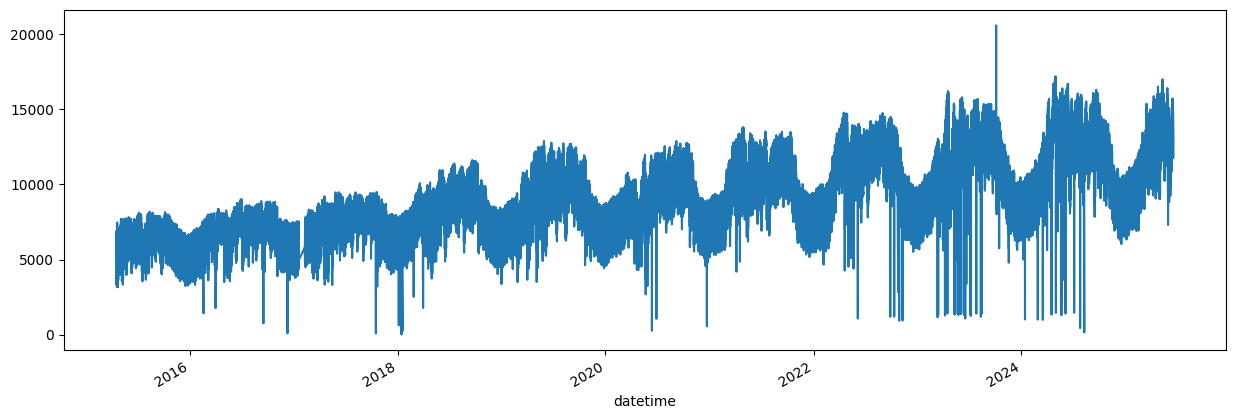

In [27]:
df['demand_mw'].plot(
    figsize=(15,5)
)

### Visualizing 'demand_mw' Time Series

This cell generates a line plot of the `demand_mw` column over time. This visualization is essential for observing the overall trend, seasonality, and any significant patterns or anomalies in electricity demand after the initial cleaning and outlier removal. The `figsize` argument sets the dimensions of the plot for better readability.

<Axes: xlabel='datetime'>

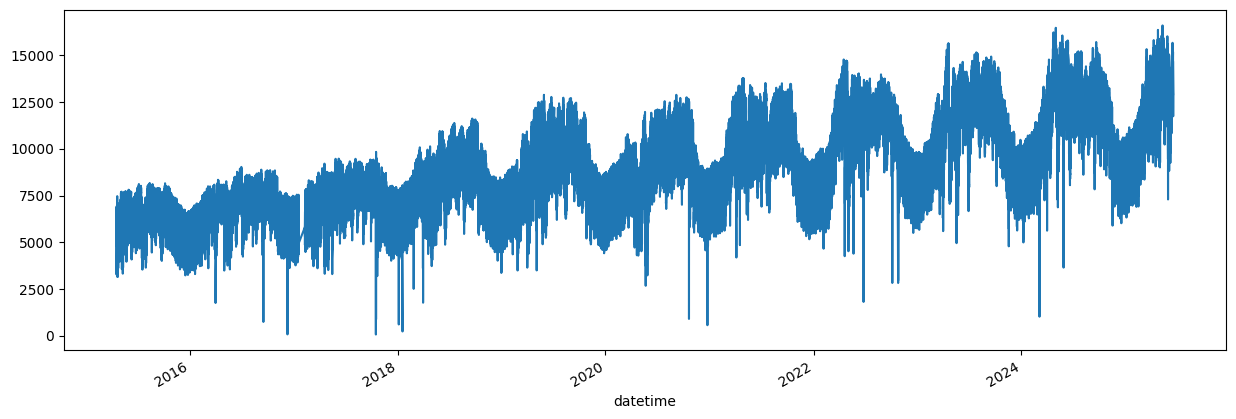

In [28]:
df['generation_mw'].plot(
    figsize=(15,5)
)

### Visualizing 'generation_mw' Time Series

This cell creates a line plot for the `generation_mw` column, similar to the demand plot. Visualizing generation alongside demand helps in understanding the relationship between the two, identifying periods of surplus or deficit, and observing how total generation capacity has evolved over the dataset's period. It also allows for a visual check for consistency with the demand patterns.

### Overall Electricity Demand and Generation Over Time

These two line plots display the raw time series data for electricity demand (`demand_mw`) and generation (`generation_mw`) in megawatts (MW) over the entire dataset period. They provide a high-level overview of how both demand and generation have evolved. Key insights from these plots include:

*   **Trends:** Observing the general upward or downward movement of demand and generation over several years.
*   **Seasonality:** Identifying recurring patterns within a year (e.g., higher demand in specific seasons).
*   **Synchronization:** Visually assessing if generation generally tracks demand, which is crucial for grid stability. Discrepancies might indicate periods of supply surplus or deficit.
*   **Anomalies:** Spotting unusual spikes or drops that could be outliers or events requiring further investigation.

In [29]:
corr = df.corr(
    numeric_only=True
)

### Calculating the Correlation Matrix

This cell calculates the pairwise correlation between all numerical columns in the DataFrame using `df.corr(numeric_only=True)`. The `numeric_only=True` argument ensures that only numerical columns are considered. The resulting `corr` DataFrame will be a square matrix where each element represents the Pearson correlation coefficient between two columns. This matrix is fundamental for understanding the linear relationships between variables, which is key for feature selection and multicollinearity assessment.

## CORRELATION MATRIX

<Axes: >

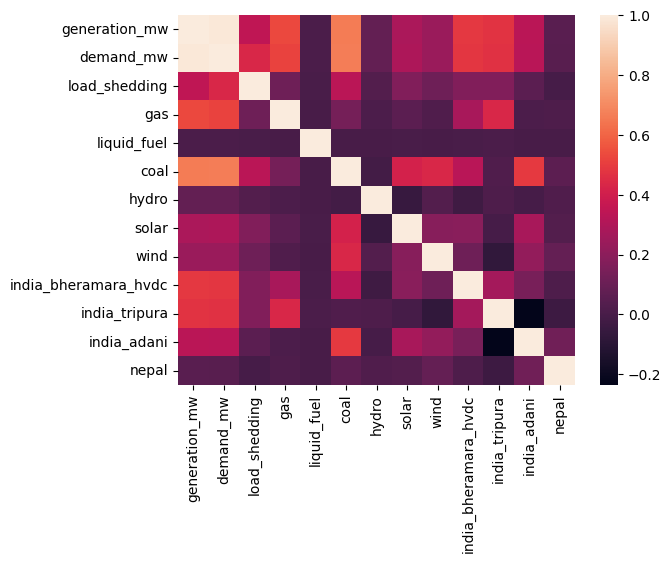

In [30]:
sns.heatmap(corr)

### Monthly Average Demand Resampling

This cell calculates the monthly average of the `demand_mw` series.

*   **`df['demand_mw'].resample('M')`**: Resamples the `demand_mw` time series data into monthly frequency. The `'M'` alias refers to month-end frequency.
*   **`.mean()`**: Computes the average demand for each month.

This operation transforms high-frequency data into a lower-frequency summary, which is useful for identifying long-term trends and seasonal patterns at a monthly granularity, smoothing out daily or hourly fluctuations.

### Correlation Matrix Heatmap

This heatmap visualizes the correlation matrix of all numeric features in your dataset. Each cell's color intensity and value indicate the strength and direction of the linear relationship between two variables. Pertaining to this project, it helps to:

*   **Identify Predictors:** Pinpoint features strongly correlated with `demand_mw` (your target variable), which are likely good predictors for forecasting models.
*   **Understand Relationships:** See how different generation sources (e.g., `gas`, `liquid_fuel`, `coal`, `solar`, `wind`) correlate with overall generation and demand.
*   **Detect Multicollinearity:** Identify highly correlated independent variables, which can be problematic for some regression models. For instance, if `generation_mw` and `demand_mw` are highly correlated (as expected), this confirms the balancing act of supply and demand.

## MONTHLY DEMAND

In [31]:
monthly = (
    df['demand_mw']
    .resample('M')
    .mean()
)

/tmp/ipykernel_4009/2567309292.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


<Axes: xlabel='datetime'>

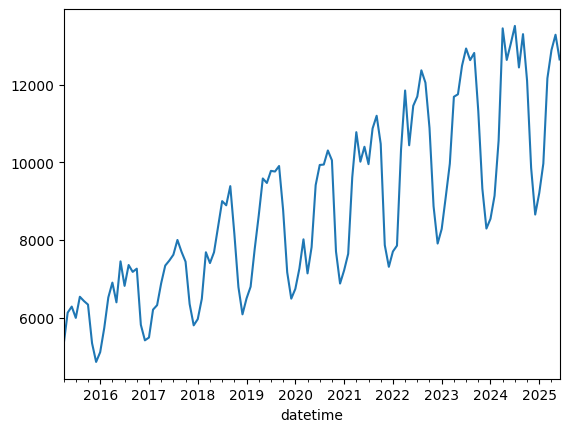

In [32]:
monthly.plot()

### Plotting Monthly Average Demand

This cell visualizes the `monthly` average demand data calculated in the previous step. A line plot is suitable for time series data, allowing clear observation of trends and seasonal cycles over months and years. This plot helps in understanding the macro-level behavior of electricity demand, revealing annual seasonality (e.g., higher demand in certain seasons) and overall growth or decline.

### Monthly Average Demand

This line plot illustrates the average electricity demand aggregated by month across the entire dataset. This visualization is crucial for understanding the long-term seasonal patterns of electricity consumption. From this plot, you can typically observe:

*   **Annual Cycles:** Clear peaks and troughs in demand that repeat each year, often corresponding to extreme weather conditions (e.g., high demand in summer for cooling, high demand in winter for heating).
*   **Seasonal Load Forecasting:** These patterns are vital for long-term capacity planning, resource allocation, and energy policy decisions.

## HOURLY PATTERN

In [33]:
df['hour'] = df.index.hour

### Extracting Hour Feature

This cell extracts the hour of the day from the DataFrame's datetime index and stores it in a new column named `hour`. This feature is critical for time series analysis, as electricity demand often exhibits strong hourly patterns (e.g., peak demand during morning and evening, low demand overnight). This explicit feature creation allows the model to learn these daily cyclic behaviors.

<Axes: xlabel='hour'>

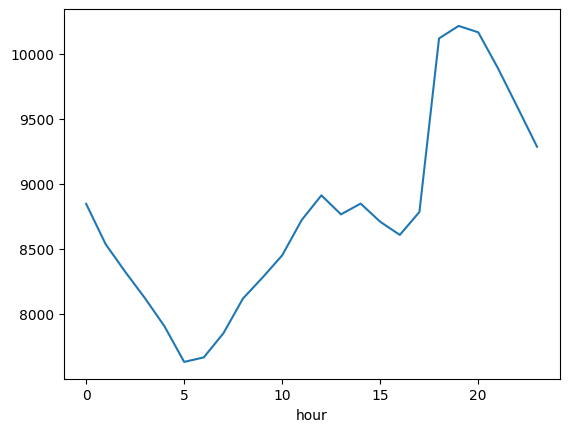

In [34]:
df.groupby(
    'hour'
)['demand_mw'].mean().plot()

### Plotting Hourly Demand Pattern

This cell groups the DataFrame by the `hour` column and calculates the mean `demand_mw` for each hour, then plots the result. This visualization clearly depicts the typical daily load profile, showing how electricity demand fluctuates throughout a 24-hour cycle. It helps identify peak demand hours and off-peak hours, which are crucial for operational planning and demand forecasting.

### Hourly Demand Pattern

This line plot shows the average electricity demand across the 24 hours of a day. It reveals the typical daily consumption cycle, which is fundamental for short-term operational planning. Key insights include:

*   **Daily Peaks:** Identifying the hours of highest demand, often occurring in the morning (e.g., wake-up, commute) and evening (e.g., cooking, entertainment).
*   **Daily Troughs:** Pinpointing periods of lowest demand, typically late night or early morning.
*   **Operational Management:** This pattern helps grid operators manage supply and demand in real-time, schedule maintenance, and optimize power plant dispatch.

## SEASOANL DECOMPOSITION

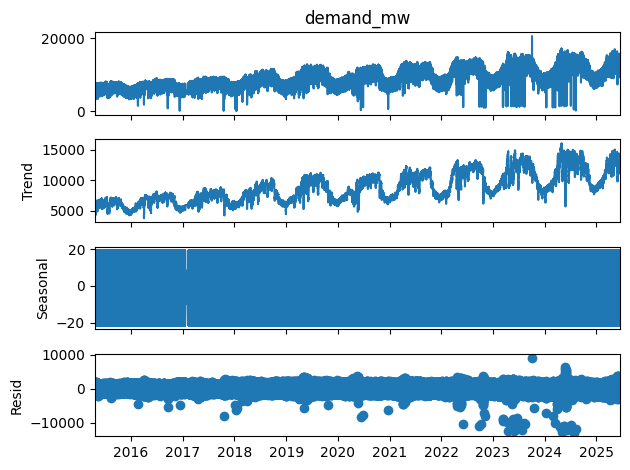

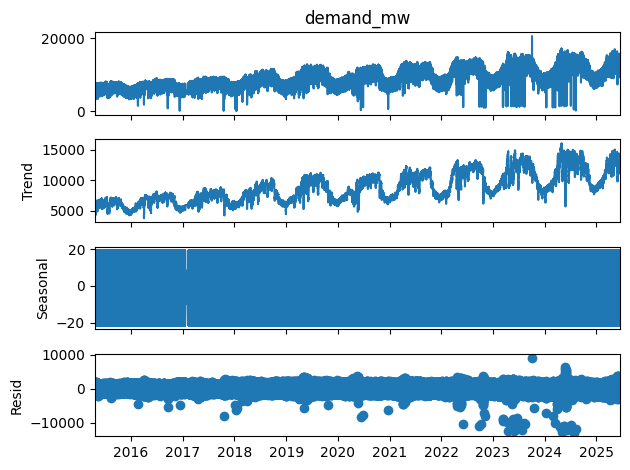

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df['demand_mw'],
    model='additive',
    period=24
)

result.plot()

### Performing Seasonal Decomposition

This cell performs a seasonal decomposition of the `demand_mw` time series using `statsmodels.tsa.seasonal.seasonal_decompose`. This method breaks down the time series into three components:

*   **Trend**: The long-term progression of the series.
*   **Seasonal**: The repeating short-term cycle, in this case, a daily cycle (period=24).
*   **Residual**: The random, unpredictable component.

By setting `model='additive'`, it assumes that the components add up to form the observed series (e.g., `observed = trend + seasonal + residual`). The `period=24` indicates a daily seasonality, crucial for understanding how demand changes predictably throughout the day.
The `result.plot()` command then visualizes these individual components, providing a detailed understanding of the underlying patterns.

### Re-extracting Hour Feature (Redundant)

This cell re-extracts the hour of the day from the DataFrame's index. This operation is redundant as the `hour` column was already created in a previous step (cell `djqenSmIuB8T`). While harmless, it's an unnecessary re-computation. It's likely a leftover from an iterative development process.

### Seasonal Decomposition of Demand

This visualization applies `seasonal_decompose` to break down the `demand_mw` time series into its fundamental components: trend, seasonal, and residual. Using an additive model with a period of 24 (suggesting a daily seasonality), this helps to:

*   **Trend Component:** Shows the underlying long-term direction of electricity demand, smoothing out daily and weekly fluctuations. This helps in understanding the overall growth or decline of electricity usage over years.
*   **Seasonal Component:** Isolates the repetitive daily pattern of demand, which is consistent with the hourly demand plot. This clearly shows the average demand behavior for each hour of the day, averaged across the entire series, free from trend and random noise.
*   **Residual Component:** Represents the unexplained variability or noise after removing the trend and seasonal effects. Analyzing residuals can highlight irregular events, anomalies, or unmodeled factors that influence demand. If the residuals show patterns, it indicates that the model has not captured all the deterministic elements of the time series.

In [36]:
df['hour'] = df.index.hour

In [37]:
df['dayofweek'] = df.index.dayofweek

### Extracting Day of Week Feature

This cell extracts the day of the week from the DataFrame's datetime index and stores it in a new column named `dayofweek`. This feature is important for capturing weekly seasonality, as electricity demand often varies significantly between weekdays and weekends. The values will range from 0 (Monday) to 6 (Sunday).

In [38]:
df['month'] = df.index.month

### Extracting Month Feature

This cell extracts the month from the DataFrame's datetime index and stores it in a new column named `month`. This feature helps to capture monthly or seasonal patterns in demand that repeat annually, complementing the daily and weekly seasonal components already extracted.

In [39]:
df['year'] = df.index.year

### Extracting Year Feature

This cell extracts the year from the DataFrame's datetime index and stores it in a new column named `year`. The `year` feature is important for capturing long-term trends and shifts in electricity demand over the entire dataset period, which might not be fully explained by daily, weekly, or monthly seasonality alone.

In [40]:
df['weekend'] = (
    df['dayofweek'] >= 5
).astype(int)

### Creating Weekend Indicator Feature

This cell creates a binary indicator column named `weekend`. It assigns `1` if the `dayofweek` is 5 (Saturday) or 6 (Sunday), and `0` otherwise. This feature explicitly captures the effect of weekends on electricity demand, as consumption patterns often differ significantly from weekdays, providing a more robust seasonal feature for modeling.

In [41]:
df.head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,hour,dayofweek,month,year,weekend
datetime,,,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,22,6,4,2015,1
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,21,6,4,2015,1
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,0.0,0.0,444,0,0.0,0.0,19,6,4,2015,1
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,0.0,0.0,444,0,0.0,0.0,18,6,4,2015,1
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,0.0,0.0,443,0,0.0,0.0,18,6,4,2015,1


### Displaying DataFrame Head with New Features

This cell displays the first few rows of the DataFrame after the creation of new time-based features (`hour`, `dayofweek`, `month`, `year`, `weekend`). This is a verification step to ensure that the new columns have been correctly added and populated, and to review their values in context with the existing data.

In [42]:
df = df.sort_index()

### Sorting DataFrame by Index

This cell sorts the DataFrame by its datetime index using `df.sort_index()`. This is a critical step for time series analysis to ensure that the data is in chronological order. Many time series operations, especially those involving lags or rolling calculations, assume a sorted index, and this step prevents potential errors or incorrect feature calculations.

In [43]:
print(df.index.is_monotonic_increasing)

True


### Checking Index Monotonicity

This cell verifies if the DataFrame's index is strictly increasing using `df.index.is_monotonic_increasing`. A `True` output confirms that the datetime index is in ascending order, which is essential for accurate time series feature engineering (like creating lagged variables) and for proper time series splitting in machine learning models.

In [44]:
df[df.index.duplicated(keep=False)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,hour,dayofweek,month,year,weekend
datetime,,,,,,,,,,,,,,,,,,
2015-04-22 21:00:00,5811.0,5811,0,4158,1021,162,30,0.0,0.0,440,0,0.0,0.0,21,2,4,2015,0
2015-04-22 21:00:00,5368.0,5368,0,4184,552,160,30,0.0,0.0,442,0,0.0,0.0,21,2,4,2015,0
2015-04-23 00:00:00,5726.0,5726,0,4199,790,158,46,0.0,0.0,433,0,0.0,0.0,0,3,4,2015,0
2015-04-23 00:00:00,3976.0,3976,0,3116,230,158,30,0.0,0.0,442,0,0.0,0.0,0,3,4,2015,0
2015-04-27 00:00:00,5236.0,5236,0,4417,159,162,46,0.0,0.0,452,0,0.0,0.0,0,0,4,2015,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-21 23:00:00,9078.0,9109,30,4665,189,2779,35,0.0,12.0,920,52,426.0,0.0,23,1,1,2025,0
2025-02-21 22:00:00,9808.0,9808,0,4720,574,2728,40,0.0,0.0,925,64,757.0,0.0,22,4,2,2025,0
2025-02-21 22:00:00,10629.0,10629,0,4517,1777,2543,40,0.0,0.0,924,70,758.0,0.0,22,4,2,2025,0


### Identifying Duplicate Timestamps

This cell identifies and displays rows where the datetime index is duplicated. The `keep=False` argument ensures that all occurrences of duplicated indices are shown. This is a crucial data quality check. Duplicate timestamps in a time series can lead to ambiguity and incorrect calculations, especially for lagged features or when resampling. Addressing these duplicates (e.g., by taking an average or removing them) is often necessary.

In [45]:
df['lag_1'] = (
    df['demand_mw']
    .shift(1)
)

In [46]:
df['lag_1']

,lag_1
datetime,
2015-04-19 00:00:00,NaN
2015-04-19 01:00:00,4821.0
2015-04-19 02:00:00,3612.0
2015-04-19 03:00:00,3727.0
2015-04-19 04:00:00,3632.0
...,...
2025-06-17 08:00:00,11745.0
2025-06-17 09:00:00,11896.0
2025-06-17 10:00:00,12290.0


### Creating Lag-1 Demand Feature

This cell creates a new feature called `lag_1` by shifting the `demand_mw` column by one period using `.shift(1)`. This `lag_1` feature represents the demand from the immediately preceding time step. Lagged features are fundamental in time series forecasting, as past values of a series are often strong predictors of future values.

In [47]:
df['lag_24'] = (
    df['demand_mw']
    .shift(24)
)

### Creating Lag-24 Demand Feature

This cell creates a `lag_24` feature by shifting `demand_mw` by 24 periods. Given the hourly nature of the data, `lag_24` represents the demand from the same hour on the previous day. This feature is highly effective at capturing daily seasonality, as electricity consumption patterns tend to repeat on a 24-hour cycle.

In [48]:
df['lag_168'] = (
    df['demand_mw']
    .shift(168)
)

### Creating Lag-168 Demand Feature

This cell creates a `lag_168` feature by shifting `demand_mw` by 168 periods (24 hours/day * 7 days/week = 168 hours/week). This feature represents the demand from the same hour on the same day of the week, one week prior. It is crucial for capturing weekly seasonality and patterns that repeat on a 7-day cycle, accounting for variations between weekdays and weekends.

In [49]:
df['rolling24'] = (
    df['demand_mw']
      .shift(1)
      .rolling(24)
      .mean()
)

df['rolling168'] = (
    df['demand_mw']
      .shift(1)
      .rolling(168)
      .mean()
)

### Creating Rolling Mean Features

This cell generates two rolling mean features based on `demand_mw`:

*   **`rolling24`**: Calculates the mean of the `demand_mw` over the previous 24 hours, shifted by one period (`.shift(1)`). This provides a smoothed representation of the demand trend over the last day, without including the current hour's demand (to avoid data leakage).
*   **`rolling168`**: Calculates the mean of `demand_mw` over the previous 168 hours (one week), also shifted by one period. This feature captures the average demand over the past week, offering a longer-term smoothed trend that can account for weekly fluctuations.

Rolling mean features help in reducing noise and capturing underlying trends, making them valuable predictors for time series models.

In [50]:
df.dropna(
    inplace=True
)

### Dropping Rows with Missing Values (from Lags/Rollings)

This cell removes any rows that contain `NaN` values using `df.dropna(inplace=True)`. After creating lagged and rolling features, the initial rows of the DataFrame will have `NaN` values because there's no preceding data for the shift/rolling window. This step ensures that the DataFrame used for modeling contains only complete observations, which is necessary for most machine learning algorithms.

In [51]:
df.head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,...,hour,dayofweek,month,year,weekend,lag_1,lag_24,lag_168,rolling24,rolling168
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-27 08:00:00,5200.0,5200,0,4425,117,171,30,0.0,0.0,457,...,8,0,4,2015,0,4800.0,4214.0,4821.0,5117.291667,5099.446429
2015-04-27 09:00:00,5430.0,5430,0,4651,118,163,40,0.0,0.0,458,...,9,0,4,2015,0,5200.0,4380.0,3612.0,5158.375000,5101.702381
2015-04-27 10:00:00,5531.0,5531,0,4710,162,161,40,0.0,0.0,458,...,10,0,4,2015,0,5430.0,4526.0,3727.0,5202.125000,5112.523810
2015-04-27 11:00:00,5602.0,5602,0,4763,187,150,45,0.0,0.0,457,...,11,0,4,2015,0,5531.0,4653.0,3632.0,5244.000000,5123.261905
2015-04-27 12:00:00,5459.0,5459,0,4445,363,148,45,0.0,0.0,458,...,12,0,4,2015,0,5602.0,4511.0,3641.0,5283.541667,5134.988095


### Displaying DataFrame Head After Feature Engineering

This cell displays the first few rows of the DataFrame (`df.head()`) after all the feature engineering steps, including the creation of lagged and rolling mean features, and subsequent `dropna()` operation. This is a final visual check to confirm that all new features are present and correctly populated, and that the DataFrame is ready for model training.

In [52]:
target = 'demand_mw'

### Defining the Target Variable

This cell defines the target variable for the predictive model. The string `'demand_mw'` is assigned to the `target` variable, explicitly indicating that the model aims to forecast electricity demand.

In [53]:
features = [
    'hour',
    'dayofweek',
    'month',
    'year',
    'weekend',
    'lag_1',
    'lag_24',
    'lag_168',
    'rolling24',
    'rolling168',
    'generation_mw',
    'gas',
    'coal',
    'solar',
    'load_shedding',
    'hydro',
    'liquid_fuel',
    'india_bheramara_hvdc',
    'india_tripura',
    'india_adani',
    'nepal'
]
X = df[features]

### Defining Features and Creating Feature Matrix (X)

This cell defines the list of independent variables (features) that will be used to predict the target variable. These include time-based features (`hour`, `dayofweek`, `month`, `year`, `weekend`), lagged demand values (`lag_1`, `lag_24`, `lag_168`), rolling means (`rolling24`, `rolling168`), and various power generation sources (`generation_mw`, `gas`, `coal`, `solar`, `load_shedding`, `hydro`, `liquid_fuel`, `india_bheramara_hvdc`, `india_tripura`, `india_adani`, `nepal`).

The DataFrame `X` is then created by selecting these columns from the main `df`, forming the feature matrix for the model.

In [54]:
y = df[target]

### Creating Target Vector (y)

This cell creates the target vector `y` by selecting the `demand_mw` column from the DataFrame. This `y` vector contains the actual values that the models will attempt to predict based on the features defined in `X`.

In [55]:
split = int(
    len(df)*0.8
)

### Defining Train-Test Split Point

This cell calculates the index for splitting the data into training and testing sets. It uses 80% of the data for training and the remaining 20% for testing. For time series data, it is crucial to perform a *chronological split* to avoid data leakage, meaning that the training set consists of older data and the test set consists of newer, unseen data.

In [56]:
X_train = X[:split]
X_test = X[split:]

### Splitting Features (X) into Training and Testing Sets

This cell divides the feature matrix `X` into training (`X_train`) and testing (`X_test`) sets based on the `split` index calculated previously. `X_train` contains the features for model training (the first 80% of the data), and `X_test` contains the features for evaluating the model's performance on unseen data (the last 20% of the data).

In [57]:
y_train = y[:split]
y_test = y[split:]

### Splitting Target (y) into Training and Testing Sets

This cell divides the target vector `y` into training (`y_train`) and testing (`y_test`) sets, mirroring the split applied to the features. `y_train` is used to train the models, and `y_test` is used to compare against the model's predictions (`lr_pred`, `rf_pred`, `xgb_pred`, `best_pred`) to evaluate performance.

In [60]:
#baseline model
lr = LinearRegression()

### Initializing Linear Regression Model

This cell initializes a `LinearRegression` model from `sklearn.linear_model`. Linear Regression serves as a simple, interpretable baseline model. It models the relationship between the independent variables and the target variable as a linear equation. This is often the first model to try and provides a benchmark against which more complex models can be compared.

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn. metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

### Importing Evaluation Metrics

This cell imports several common regression evaluation metrics from `sklearn.metrics`:

*   **`mean_squared_error`**: Measures the average of the squares of the errors, penalizing larger errors more heavily.
*   **`mean_absolute_error`**: Measures the average absolute difference between predicted and actual values, providing a straightforward interpretation of average error.
*   **`mean_absolute_percentage_error`**: Expresses the error as a percentage of the actual value, useful for understanding forecast accuracy relative to the magnitude of the demand.
*   **`r2_score`**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables (R-squared), indicating how well the model explains the variability of the target.

In [61]:
lr.fit(
    X_train,
    y_train
)

LinearRegression()

### Training the Linear Regression Model

This cell trains the initialized `LinearRegression` model using the `X_train` (training features) and `y_train` (training target). The `fit()` method learns the optimal coefficients for the linear equation that best describes the relationship between the features and the demand in the training data.

In [62]:
lr_pred = lr.predict(
    X_test
)

### Making Predictions with Linear Regression

This cell uses the trained `LinearRegression` model (`lr`) to make predictions on the unseen test feature set (`X_test`). The `predict()` method outputs the estimated `demand_mw` values, which will then be compared against the actual `y_test` values to evaluate the model's performance.

In [63]:
mae = mean_absolute_error(
    y_test,
    lr_pred
)

### Calculating Mean Absolute Error (MAE) for Linear Regression

This cell calculates the Mean Absolute Error (MAE) for the Linear Regression model. MAE quantifies the average magnitude of the errors in a set of predictions, without considering their direction. It's the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight. A lower MAE indicates a better performing model.

In [64]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

### Calculating Root Mean Squared Error (RMSE) for Linear Regression

This cell calculates the Root Mean Squared Error (RMSE) for the Linear Regression model. RMSE is the square root of the average of the squared differences between prediction and actual observation. It gives a relatively high weight to large errors, meaning it is most useful when large errors are particularly undesirable. Like MAE, a lower RMSE indicates better model performance.

### Calculating R-squared (R2) for Linear Regression

This cell calculates the R-squared (R2) score for the Linear Regression model. R2 represents the proportion of the variance in the dependent variable (demand_mw) that is predictable from the independent variables. An R2 score closer to 1 indicates that a larger proportion of variance is explained by the model, suggesting a better fit. A score of 0 indicates that the model explains none of the variability of the response data around its mean.

In [65]:
r2 = r2_score(
    y_test,
    lr_pred
)

In [66]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

### Initializing Random Forest Regressor Model

This cell initializes a `RandomForestRegressor` model from `sklearn.ensemble`. Random Forest is an ensemble learning method that constructs a multitude of decision trees during training and outputs the mean prediction of the individual trees. It is robust to overfitting and capable of handling non-linear relationships. The `n_estimators` parameter sets the number of trees in the forest, and `random_state` ensures reproducibility.

In [67]:
rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, random_state=42)

### Training the Random Forest Regressor Model

This cell trains the initialized `RandomForestRegressor` model using the `X_train` (training features) and `y_train` (training target). The `fit()` method builds the ensemble of decision trees, each learning from a bootstrapped sample of the data and a random subset of features.

In [68]:
rf_pred = rf.predict(
    X_test
)

### Making Predictions with Random Forest Regressor

This cell uses the trained `RandomForestRegressor` model (`rf`) to make predictions on the unseen test feature set (`X_test`). The `predict()` method aggregates the predictions from all individual decision trees in the forest to produce the final demand forecast.

In [69]:
mae = mean_absolute_error(
    y_test,
    rf_pred
)

### Calculating Mean Absolute Error (MAE) for Random Forest

This cell calculates the Mean Absolute Error (MAE) for the Random Forest model's predictions against the actual `y_test` values. This metric provides a clear, interpretable measure of the average absolute difference between the model's forecasts and the true electricity demand.

In [70]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

### Calculating Root Mean Squared Error (RMSE) for Random Forest

This cell calculates the Root Mean Squared Error (RMSE) for the Random Forest model. RMSE provides a measure of the average magnitude of the errors, giving more weight to larger errors due to the squaring operation. It is a common metric to assess the overall accuracy of regression models.

In [71]:
r2 = r2_score(
    y_test,
    rf_pred
)

### Calculating R-squared (R2) for Random Forest

This cell calculates the R-squared (R2) score for the Random Forest model. This metric indicates the proportion of the variance in electricity demand that can be explained by the Random Forest model, providing an insight into its explanatory power on the test data.

In [72]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

### Initializing XGBoost Regressor Model

This cell initializes an `XGBRegressor` model from the `xgboost` library. XGBoost (Extreme Gradient Boosting) is a highly efficient and popular gradient boosting framework known for its speed and performance in machine learning competitions. It's an ensemble technique that sequentially builds decision trees, with each new tree correcting errors made by previous ones. `objective='reg:squarederror'` specifies a regression task with squared error loss, and `random_state` ensures reproducibility.

In [73]:
xgb.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### Training the XGBoost Regressor Model

This cell trains the initialized `XGBRegressor` model using the `X_train` (training features) and `y_train` (training target). The `fit()` method builds the gradient-boosted trees, iteratively optimizing the model to minimize the prediction errors on the training data.

In [74]:
xgb_pred = xgb.predict(
    X_test
)

### Making Predictions with XGBoost Regressor

This cell uses the trained `XGBRegressor` model (`xgb`) to make predictions on the unseen test feature set (`X_test`). The `predict()` method combines the outputs of all the individual trees to generate the final demand forecasts.

In [75]:
mae = mean_absolute_error(
    y_test,
    xgb_pred
)

### Calculating Mean Absolute Error (MAE) for XGBoost

This cell calculates the Mean Absolute Error (MAE) for the XGBoost model's predictions. This metric provides the average absolute difference between the predicted and actual electricity demand values on the test set.

In [76]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

### Calculating Root Mean Squared Error (RMSE) for XGBoost

This cell calculates the Root Mean Squared Error (RMSE) for the XGBoost model. RMSE is a robust metric that penalizes larger errors more, providing a comprehensive measure of the model's accuracy on the test data.

In [77]:
r2 = r2_score(
    y_test,
    xgb_pred
)

### Calculating R-squared (R2) for XGBoost

This cell calculates the R-squared (R2) score for the XGBoost model. It quantifies the proportion of variance in the electricity demand that the XGBoost model can explain, offering an insight into its overall goodness of fit.

In [78]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(
    n_splits=5
)

### Initializing TimeSeriesSplit for Cross-Validation

This cell initializes `TimeSeriesSplit` from `sklearn.model_selection`. This cross-validation strategy is specifically designed for time series data. Unlike standard K-Fold cross-validation, `TimeSeriesSplit` divides data into folds where the training sets are always prior to the validation sets, preserving the temporal order. This is crucial for realistic evaluation of time series models. `n_splits=5` means the data will be split into 5 progressively larger training sets and corresponding testing sets.

In [79]:
param_grid = {

'n_estimators':[100,200,500],

'max_depth':[3,5,7],

'learning_rate':[0.01,0.05,0.1],

'subsample':[0.8,1.0],

'colsample_bytree':[0.8,1.0]

}

### Defining Hyperparameter Grid for Randomized Search

This cell defines `param_grid`, a dictionary specifying the range of hyperparameters to search for tuning the XGBoost model. This grid includes:

*   **`n_estimators`**: Number of boosting rounds (trees).
*   **`max_depth`**: Maximum depth of a tree.
*   **`learning_rate`**: Step size shrinkage to prevent overfitting.
*   **`subsample`**: Fraction of samples used for fitting the trees.
*   **`colsample_bytree`**: Fraction of features (columns) randomly sampled for each tree.

This grid will be used by `RandomizedSearchCV` to explore different combinations of these parameters.

In [80]:
from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    cv=tscv,
    n_iter=30,
    n_jobs=-1
)

### Initializing Randomized Search for Hyperparameter Tuning

This cell initializes `RandomizedSearchCV` from `sklearn.model_selection` for hyperparameter optimization of the XGBoost model. Instead of an exhaustive grid search, `RandomizedSearchCV` samples a fixed number (`n_iter=30`) of parameter settings from the specified distribution (`param_distributions`). This makes it computationally more efficient while still effectively exploring the hyperparameter space.

*   **`estimator=xgb`**: The XGBoost model to be tuned.
*   **`param_distributions=param_grid`**: The dictionary of hyperparameters to sample from.
*   **`cv=tscv`**: Uses the `TimeSeriesSplit` for appropriate time series cross-validation.
*   **`n_iter=30`**: Number of parameter settings that are sampled.
*   **`n_jobs=-1`**: Utilizes all available CPU cores for parallel processing, speeding up the search.

In [81]:
search.fit(
    X_train,
    y_train
)


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 500],
                                        'subsample': [0.8, 1.0]})

### Executing Randomized Search for Hyperparameter Tuning

This cell executes the `RandomizedSearchCV` process by calling the `fit()` method on the training data (`X_train`, `y_train`). During this process, the model performs cross-validation across the defined `TimeSeriesSplit` folds, evaluates different hyperparameter combinations, and identifies the set of parameters that yield the best performance (typically minimizing a specified metric like RMSE, though it defaults to R-squared for regressors unless specified).

The output shows the configuration of the `RandomizedSearchCV` object after fitting.

In [82]:
best_model = (
    search.best_estimator_
)

### Retrieving the Best Tuned Model

This cell retrieves the best-performing estimator (XGBoost model) found during the `RandomizedSearchCV` process. The `search.best_estimator_` attribute holds the model instance trained with the optimal hyperparameters identified during tuning. This `best_model` will then be used for making final predictions and evaluation.

In [83]:
best_pred = (
    best_model.predict(
        X_test
    )
)

### Making Predictions with the Best Tuned XGBoost Model

This cell uses the `best_model` (the hyperparameter-tuned XGBoost Regressor) to make predictions on the unseen test feature set (`X_test`). These predictions (`best_pred`) represent the model's final forecasts for electricity demand, using the optimized parameters found during the randomized search.

In [84]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, mape, r2

### Defining Model Evaluation Function

This cell defines a reusable function `evaluate_model` to calculate and return multiple regression evaluation metrics. This function takes the true values (`y_true`) and predicted values (`y_pred`) as input and computes:

*   **Mean Absolute Error (MAE)**
*   **Root Mean Squared Error (RMSE)**
*   **Mean Absolute Percentage Error (MAPE)** (multiplied by 100 for percentage representation)
*   **R-squared (R2)**

This centralizes the calculation of metrics, ensuring consistency and reducing code duplication when evaluating different models.

In [85]:
lr_mae, lr_rmse, lr_mape, lr_r2 = evaluate_model(
    y_test,
    lr_pred
)

### Evaluating Linear Regression Model

This cell uses the `evaluate_model` function to calculate the MAE, RMSE, MAPE, and R2 scores for the Linear Regression model's predictions (`lr_pred`) against the actual test values (`y_test`). The results are stored in corresponding variables for later comparison.

In [86]:
rf_mae, rf_rmse, rf_mape, rf_r2 = evaluate_model(
    y_test,
    rf_pred
)

### Evaluating Random Forest Model

This cell applies the `evaluate_model` function to assess the performance of the Random Forest model. It calculates MAE, RMSE, MAPE, and R2 based on `rf_pred` (Random Forest predictions) and `y_test` (actual test values), storing the metrics in dedicated variables.

In [87]:
xgb_mae, xgb_rmse, xgb_mape, xgb_r2 = evaluate_model(
    y_test,
    xgb_pred
)

### Evaluating XGBoost Model (Untuned)

This cell evaluates the performance of the untuned XGBoost model by calling the `evaluate_model` function with `xgb_pred` (XGBoost predictions) and `y_test`. The calculated MAE, RMSE, MAPE, and R2 metrics are stored for direct comparison with other models, including the tuned XGBoost.

In [88]:
tuned_mae, tuned_rmse, tuned_mape, tuned_r2 = evaluate_model(
    y_test,
    best_pred
)

### Evaluating Tuned XGBoost Model

This cell evaluates the performance of the hyperparameter-tuned XGBoost model. It utilizes the `evaluate_model` function with `best_pred` (predictions from the tuned model) and `y_test` to compute the final MAE, RMSE, MAPE, and R2 scores. These metrics are crucial for determining the effectiveness of the hyperparameter optimization.

In [89]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],

    "MAE":[
        lr_mae,
        rf_mae,
        xgb_mae,
        tuned_mae
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse,
        xgb_rmse,
        tuned_rmse
    ],

    "MAPE (%)":[
        lr_mape,
        rf_mape,
        xgb_mape,
        tuned_mape
    ],

    "R²":[
        lr_r2,
        rf_r2,
        xgb_r2,
        tuned_r2
    ]

})

### Compiling Model Performance Results

This cell creates a pandas DataFrame named `results` to consolidate the evaluation metrics (MAE, RMSE, MAPE, R2) for all trained models: Linear Regression, Random Forest, untuned XGBoost, and tuned XGBoost. This structured format makes it easy to compare the performance of different models side-by-side.

In [90]:
results = results.round(3)

### Rounding Performance Metrics

This cell rounds all numerical values in the `results` DataFrame to three decimal places using `results.round(3)`. This step improves the readability of the evaluation metrics, making the comparison between models clearer and more concise.

In [91]:
print(results)

               Model      MAE     RMSE  MAPE (%)     R²
0  Linear Regression   37.143  448.186     2.292  0.963
1      Random Forest  253.854  770.546     3.096  0.892
2            XGBoost  423.992  961.193     4.506  0.831
3      Tuned XGBoost  247.087  561.741     3.306  0.942


### Displaying Model Performance Summary

This cell prints the `results` DataFrame, which contains the rounded evaluation metrics for all models. This output provides a comprehensive summary of how each model performed across MAE, RMSE, MAPE, and R-squared, allowing for a direct comparison to identify the most effective model for forecasting electricity demand.

In [92]:
best = results.loc[results["RMSE"].idxmin()]

print("Best Model")
print(best)

Best Model
Model       Linear Regression
MAE                    37.143
RMSE                  448.186
MAPE (%)                2.292
R²                      0.963
Name: 0, dtype: object


### Identifying the Best Performing Model

This cell identifies the best-performing model based on the Root Mean Squared Error (RMSE). It finds the index of the minimum RMSE value in the `results` DataFrame (`results["RMSE"].idxmin()`) and then retrieves the entire row corresponding to that model. The information for the "Best Model" is then printed, explicitly highlighting the model with the lowest RMSE.

In [93]:
#Investigation 1: Verify the Time-Based Split
#Checking the Split Dates
print("Training Start :", X_train.index.min())
print("Training End   :", X_train.index.max())

print()

print("Testing Start  :", X_test.index.min())
print("Testing End    :", X_test.index.max())

Training Start : 2015-04-27 08:00:00
Training End   : 2023-06-10 06:00:00

Testing Start  : 2023-06-10 07:00:00
Testing End    : 2025-06-17 12:00:00


### Verifying Time-Based Split Dates

This cell prints the minimum and maximum datetime values for both the training and testing sets of the feature matrix (`X_train` and `X_test`). This is a critical verification step for time series analysis to confirm that the data has been split chronologically, ensuring that the model is trained on past data and evaluated on future, unseen data, preventing data leakage.

In [94]:
#Checking the Number of Samples
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 73766
Testing samples : 18442


### Verifying Number of Samples in Training and Testing Sets

This cell prints the number of samples (rows) in both the `X_train` and `X_test` datasets. This confirms that the 80/20 split (or whatever proportion was chosen) was correctly applied and shows the exact sizes of the datasets used for training and testing the models.

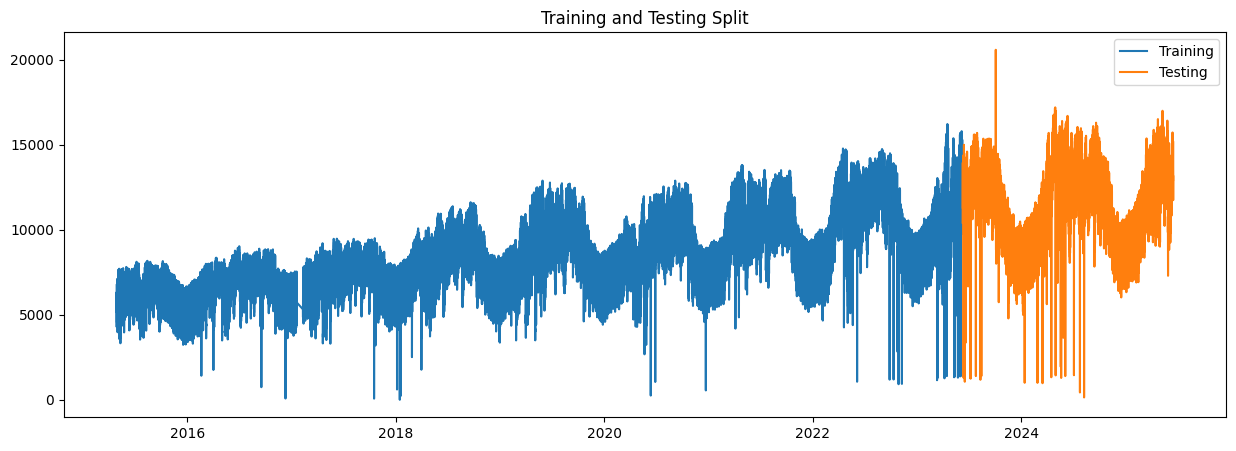

In [95]:
#Visualizing the Split
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    y_train,
    label="Training"
)

plt.plot(
    y_test,
    label="Testing"
)

plt.legend()

plt.title("Training and Testing Split")

plt.show()

### Visualizing Training and Testing Split

This cell generates a plot that visually represents the split of the `demand_mw` time series into training and testing sets.

*   It plots `y_train` (the training segment of the target variable) and `y_test` (the testing segment).
*   The legend, title, and `plt.show()` enhance clarity.

This visualization provides an immediate confirmation that the chronological split has been correctly applied, with the training data preceding the testing data. This is crucial for valid time series model evaluation.

### Training and Testing Split Visualization

This plot visually represents the division of your `demand_mw` time series data into training and testing sets. This is a critical step in time series forecasting:

*   **Chronological Split:** The plot clearly shows that the training data (`y_train`) comprises the earlier part of the time series, while the testing data (`y_test`) consists of the later, unseen data. This is essential for time series models, as they must learn from past data to predict future values.
*   **Model Evaluation:** The model is trained on the 'Training' segment and its performance is evaluated on the 'Testing' segment. This visual check ensures that your data split maintains the temporal order, preventing data leakage and providing a realistic assessment of the model's predictive power on new data.

In [96]:
#Investigation 2: Verifying Feature Construction
df[['demand_mw','lag_1','lag_24','lag_168']].head(30)

,demand_mw,lag_1,lag_24,lag_168
datetime,,,,
2015-04-27 08:00:00,5200,4800.0,4214.0,4821.0
2015-04-27 09:00:00,5430,5200.0,4380.0,3612.0
2015-04-27 10:00:00,5531,5430.0,4526.0,3727.0
2015-04-27 11:00:00,5602,5531.0,4653.0,3632.0
2015-04-27 12:00:00,5459,5602.0,4511.0,3641.0
2015-04-27 13:00:00,5424,5459.0,4928.0,3283.0
2015-04-27 14:00:00,5630,5424.0,5725.0,3444.0
2015-04-27 15:00:00,5569,5630.0,4623.0,3592.0
2015-04-27 16:00:00,5300,5569.0,6187.0,4049.0


### Verifying Lagged Features

This cell displays the first 30 rows of the 'demand_mw' column along with its lagged counterparts (`lag_1`, `lag_24`, `lag_168`). This is an important step to visually inspect and confirm that the lagged features have been correctly generated. For example, `lag_1` for a given timestamp should match the `demand_mw` of the previous timestamp, `lag_24` should match the demand from 24 hours prior, and so on. This helps in identifying any inconsistencies or errors in the feature engineering process.

In [97]:
#Verifying Rolling Features
time_diff = df.index.to_series().diff()

print(time_diff.value_counts().head(10))

datetime
0 days 01:00:00    83410
0 days 00:30:00     8304
0 days 02:00:00      225
0 days 00:00:00      214
0 days 03:00:00       13
0 days 01:30:00       10
0 days 11:00:00        4
0 days 09:00:00        4
0 days 12:00:00        4
0 days 07:00:00        3
Name: count, dtype: int64


### Verifying Time Differences and Data Regularity

This cell analyzes the time differences between consecutive entries in the DataFrame's index.

*   **`df.index.to_series().diff()`**: Calculates the difference between each datetime index and the previous one.
*   **`.value_counts().head(10)`**: Counts the occurrences of each time difference and displays the top 10 most frequent ones.

This analysis is crucial for understanding the regularity of the time series data. Ideally, for hourly data, the most frequent difference should be '0 days 01:00:00'. Significant variations or presence of '0 days 00:00:00' (duplicate timestamps not dropped) or other large gaps indicate irregular sampling intervals, which can impact time series modeling and the reliability of rolling features.

In [98]:
#Checking for overfitting
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Training")
print(evaluate_model(y_train, train_pred))

print("Testing")
print(evaluate_model(y_test, test_pred))

Training
(35.53316879272461, np.float64(136.53875651715157), 1.5889989212155342, 0.9962971210479736)
Testing
(247.0869140625, np.float64(561.7414607717682), 3.3061139285564423, 0.9424256682395935)


### Checking for Overfitting through Training vs. Testing Performance

This cell evaluates the performance of the `best_model` (tuned XGBoost) on both the training set and the test set using the `evaluate_model` function.

*   **`train_pred = best_model.predict(X_train)`**: Makes predictions on the training data.
*   **`test_pred = best_model.predict(X_test)`**: Makes predictions on the unseen test data.

By comparing the metrics (MAE, RMSE, MAPE, R2) between the training and testing sets, this step helps to detect overfitting. If the model performs significantly better on the training set than on the testing set, it suggests that the model has learned the training data too well, including its noise, and may not generalize effectively to new data.

In [99]:
#Residual analysis
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": best_pred
})

comparison["Residual"] = comparison["Actual"] - comparison["Predicted"]
comparison["Abs_Error"] = comparison["Residual"].abs()

### Preparing for Residual Analysis

This cell creates a new DataFrame named `comparison` to facilitate detailed residual analysis of the `best_model`'s predictions.

*   It combines the `y_test` (actual values) and `best_pred` (predicted values).
*   **`comparison["Residual"] = comparison["Actual"] - comparison["Predicted"]`**: Calculates the residual (the difference between actual and predicted values).
*   **`comparison["Abs_Error"] = comparison["Residual"].abs()`**: Calculates the absolute error, representing the magnitude of the error irrespective of its direction.

This DataFrame is a foundational step for further investigation into where and why the model makes errors, especially large ones.

In [100]:
comparison.sort_values(
    "Abs_Error",
    ascending=False
).head(20)

,Actual,Predicted,Residual,Abs_Error
datetime,,,,
2024-07-25 10:00:00,436,14007.354492,-13571.354492,13571.354492
2024-05-01 05:00:00,1440,14445.279297,-13005.279297,13005.279297
2024-08-08 23:00:00,143,13054.046875,-12911.046875,12911.046875
2023-07-26 15:00:00,1400,14208.129883,-12808.129883,12808.129883
2023-08-14 21:00:00,1400,13922.309570,-12522.309570,12522.309570
2024-04-16 01:00:00,1330,12860.293945,-11530.293945,11530.293945
2024-05-20 15:00:00,1290,12664.852539,-11374.852539,11374.852539
2023-06-13 12:00:00,1300,12577.181641,-11277.181641,11277.181641
2023-07-08 01:00:00,1245,12480.265625,-11235.265625,11235.265625


### Inspecting Largest Absolute Errors

This cell sorts the `comparison` DataFrame by `Abs_Error` in descending order and displays the top 20 rows. This allows for a focused examination of the instances where the `best_model` made the largest prediction errors. By looking at these specific timestamps and their corresponding actual and predicted values, one can gain insights into potential issues such as:

*   **Unusual events**: Dates with unexpected demand spikes or drops that the model failed to capture.
*   **Data quality issues**: Underlying erroneous data points that were not fully addressed during cleaning.
*   **Model limitations**: Scenarios where the model's features or architecture might not be sufficient to explain certain demand behaviors.

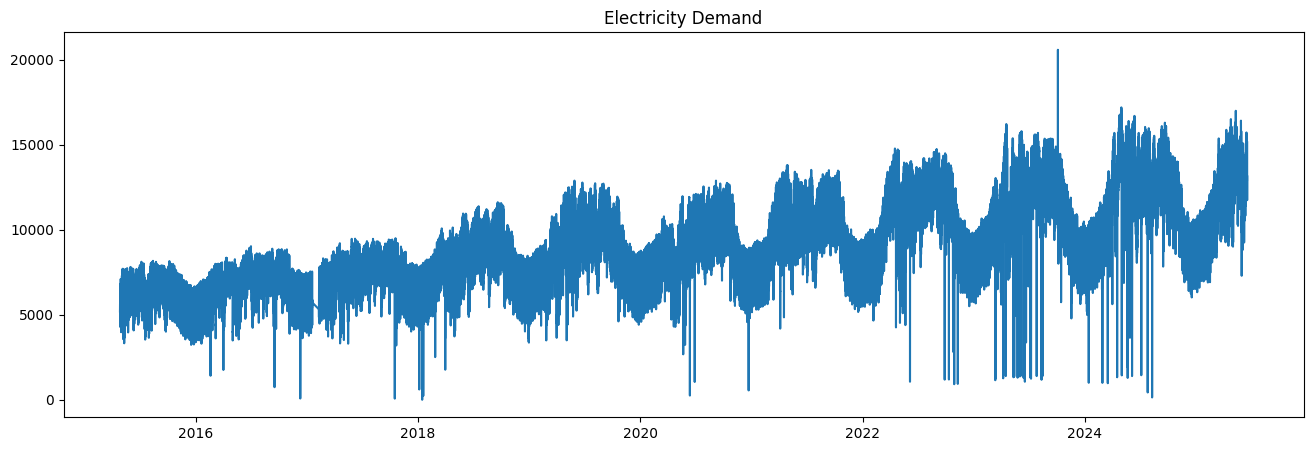

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,5))
plt.plot(df["demand_mw"])
plt.title("Electricity Demand")
plt.show()

### Visualizing the Overall Electricity Demand

This cell generates a single line plot of the entire `demand_mw` series. This visualization serves as a broad overview of the target variable's behavior across the entire dataset. It allows for a quick assessment of overall trends, seasonality, and the range of demand values. It's a fundamental step for understanding the target distribution before detailed analysis or modeling.

In [102]:
print(df["demand_mw"].describe())

count    92208.000000
mean      8823.486650
std       2614.334261
min          6.000000
25%       6824.750000
50%       8435.000000
75%      10641.250000
max      20587.000000
Name: demand_mw, dtype: float64


### Descriptive Statistics for 'demand_mw'

This cell prints the descriptive statistics for the `demand_mw` column using `df["demand_mw"].describe()`. This provides a quantitative summary of the target variable, including count, mean, standard deviation, minimum, maximum, and quartiles. This is useful for understanding the central tendency, spread, and range of electricity demand after all cleaning and filtering steps have been applied.

In [103]:
print(df["demand_mw"].nsmallest(20))

datetime
2018-01-14 11:00:00       6
2017-10-16 09:00:00      73
2016-12-09 20:00:00      80
2024-08-08 23:00:00     143
2018-01-17 23:00:00     236
2020-06-12 02:00:00     254
2024-07-25 10:00:00     436
2020-12-22 04:00:00     556
2018-01-04 20:00:00     611
2016-09-16 06:00:00     746
2022-10-28 17:00:00     921
2022-11-09 10:00:00     940
2024-03-16 07:00:00     980
2024-02-27 14:00:00    1000
2024-01-13 17:00:00    1005
2020-06-27 22:00:00    1053
2022-06-05 09:00:00    1067
2023-06-17 18:30:00    1067
2023-03-12 15:00:00    1156
2023-03-12 14:00:00    1168
Name: demand_mw, dtype: int64


### Identifying Smallest Demand Values

This cell prints the 20 smallest values in the `demand_mw` column, along with their corresponding timestamps, using `df["demand_mw"].nsmallest(20)`. This helps in identifying:

*   **Potential outliers**: Extremely low demand values that might be data errors or represent unusual operating conditions.
*   **Anomalies**: Unexpected dips in demand that could correspond to holidays, blackouts, or other significant events.

Examining these values can inform further data cleaning or contextual understanding.

In [104]:
print(df["demand_mw"].nlargest(20))

datetime
2023-10-04 09:00:00    20587
2024-04-29 20:00:00    17200
2024-04-28 20:00:00    17150
2024-04-29 21:00:00    17100
2024-04-29 22:00:00    17100
2024-04-30 20:00:00    17000
2025-05-10 20:00:00    17000
2024-04-28 21:00:00    16900
2024-04-29 19:00:00    16900
2024-04-29 23:00:00    16900
2024-04-28 22:00:00    16850
2024-04-29 18:30:00    16850
2024-04-30 19:00:00    16850
2025-05-10 19:00:00    16850
2024-04-28 18:30:00    16800
2024-04-30 18:30:00    16800
2024-04-24 20:00:00    16774
2024-04-25 18:30:00    16750
2024-04-27 18:30:00    16750
2024-04-27 19:00:00    16750
Name: demand_mw, dtype: int64


### Identifying Largest Demand Values

This cell prints the 20 largest values in the `demand_mw` column, along with their corresponding timestamps, using `df["demand_mw"].nlargest(20)`. This is useful for identifying:

*   **Peak demand periods**: Times when electricity consumption was at its highest, often corresponding to specific hours of the day or seasons.
*   **Potential outliers**: Extremely high demand values that might be erroneous or represent rare, high-consumption events.

Analyzing these peaks is critical for capacity planning and understanding demand drivers.